# Session 16 - Correlation Analysis

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

## Task 1 — Pearson Correlation: Danceability vs Popularity (12 Songs)

Dataset created manually (song audio features + popularity score) since no file was specified.

In [2]:
songs = pd.DataFrame({
    'song': [f'Song_{i}' for i in range(1, 13)],
    'danceability': [0.72, 0.55, 0.88, 0.40, 0.65, 0.78, 0.50, 0.82, 0.35, 0.60, 0.90, 0.45],
    'energy':       [0.65, 0.80, 0.70, 0.55, 0.60, 0.75, 0.45, 0.68, 0.50, 0.58, 0.72, 0.62],
    'popularity':   [75, 68, 89, 48, 66, 80, 58, 84, 44, 70, 92, 52],
})
print(songs)

pearson_r = songs['danceability'].corr(songs['popularity'])
print('\nPearson correlation (danceability vs popularity):', pearson_r)

       song  danceability  energy  popularity
0    Song_1          0.72    0.65          75
1    Song_2          0.55    0.80          68
2    Song_3          0.88    0.70          89
3    Song_4          0.40    0.55          48
4    Song_5          0.65    0.60          66
5    Song_6          0.78    0.75          80
6    Song_7          0.50    0.45          58
7    Song_8          0.82    0.68          84
8    Song_9          0.35    0.50          44
9   Song_10          0.60    0.58          70
10  Song_11          0.90    0.72          92
11  Song_12          0.45    0.62          52

Pearson correlation (danceability vs popularity): 0.9855861576334036


## Task 2 — Spearman Correlation: IPL Runs vs Instagram Followers

In [6]:
ipl = pd.DataFrame({
    'player': [f'Player_{i}' for i in range(1, 11)],
    'total_runs': [5000, 8500, 3200, 6200, 4100, 7300, 2800, 9000, 5600, 3900],
    'instagram_followers_millions': [15.2, 25.6, 8.1, 18.4, 10.5, 22.0, 6.5, 30.2, 14.8, 9.9],
})
print(ipl)

rho, p_value = spearmanr(ipl['total_runs'], ipl['instagram_followers_millions'])
print('\nSpearman correlation:', rho)
print('p-value:', p_value)

      player  total_runs  instagram_followers_millions
0   Player_1        5000                          15.2
1   Player_2        8500                          25.6
2   Player_3        3200                           8.1
3   Player_4        6200                          18.4
4   Player_5        4100                          10.5
5   Player_6        7300                          22.0
6   Player_7        2800                           6.5
7   Player_8        9000                          30.2
8   Player_9        5600                          14.8
9  Player_10        3900                           9.9

Spearman correlation: 0.9878787878787878
p-value: 9.307459988955518e-08


**Interpretation:** ρ ≈ 0.988 is a very strong positive correlation — in this sample, players with more career runs consistently have more Instagram followers too. That tracks: high run-scorers get more visibility (match awards, highlight reels, sponsorships), which plausibly drives follower growth — though this doesn't prove runs *cause* followers, since fame from other sources (IPL auctions, T20 hitting style, off-field presence) likely plays a role too.

## Task 3 — Correlation Matrix: Flipkart Price, Rating, Reviews

In [7]:
flipkart = pd.DataFrame({
    'price':   [999, 1499, 599, 2999, 799, 1999, 499, 3499, 1299, 899],
    'rating':  [4.2, 4.4, 3.8, 4.6, 4.0, 4.3, 3.6, 4.7, 4.1, 3.9],
    'reviews': [1200, 850, 2100, 430, 1650, 610, 2450, 310, 980, 1400],
})

corr_matrix = flipkart.corr()
print(corr_matrix)

            price    rating   reviews
price    1.000000  0.914604 -0.869355
rating   0.914604  1.000000 -0.949502
reviews -0.869355 -0.949502  1.000000


## Task 4 — Heatmap of the Correlation Matrix

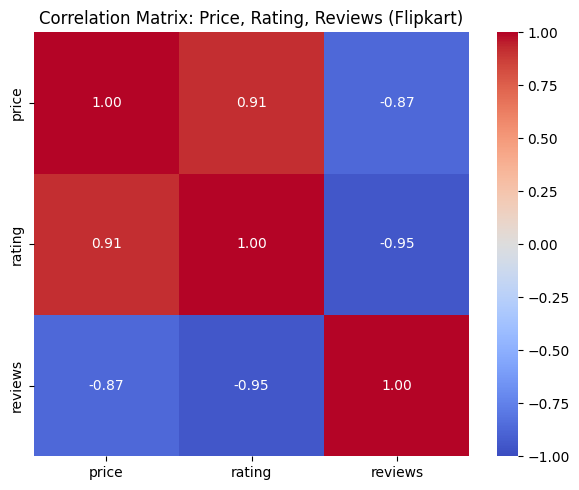

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f', cbar=True)
plt.title('Correlation Matrix: Price, Rating, Reviews (Flipkart)')
plt.tight_layout()
plt.show()

## Task 5 — Two Pitfalls When Interpreting Correlation

**1. Correlation isn't causation.** A Zomato analyst might find that restaurants running more promotional offers have higher order volume and conclude the offers *drive* orders — but it could just as easily be that already-popular restaurants run more offers because they can afford to, with popularity driving both the offers and the order volume rather than the offers driving orders.

**2. A third (confounding) variable can create a misleading correlation.** On YouTube, video length might show a positive correlation with watch time — but both are likely driven by a hidden third factor: content quality or niche (tutorials and podcasts run long *and* hold attention well). Treating length itself as the lever would be misleading; simply making unrelated videos longer wouldn't reproduce that same watch-time boost.